# Definição de Métricas — Churn Detection

Este notebook estabelece as métricas que guiarão todas as decisões de modelagem:

- **Métricas técnicas**: AUC-ROC, PR-AUC e F1-Score
- **Métrica de negócio**: custo de churn evitado

O dataset é o Telco Customer Churn (~7 k clientes), com taxa de churn de ~26 %.

In [6]:
import hashlib
import os
import subprocess

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

DATA_PATH = "../data/raw/telco_churn.csv"
df = pd.read_csv(DATA_PATH)

# Limpeza básica
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(f"Shape: {df.shape}")
print(f"Taxa de churn: {df['Churn'].mean():.1%}")
df.head(3)

Shape: (7032, 21)
Taxa de churn: 26.6%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


## MLflow — setup

In [7]:
MLFLOW_TRACKING_URI = "../mlruns"
EXPERIMENT_NAME     = "churn-metrics-definition"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

def _file_md5(path: str) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

def _git_commit() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=os.path.dirname(os.path.abspath(DATA_PATH)),
            stderr=subprocess.DEVNULL,
        ).decode().strip()
    except Exception:
        return "unknown"

DATASET_MD5    = _file_md5(DATA_PATH)
DATASET_COMMIT = _git_commit()
print(f"Experimento : {EXPERIMENT_NAME}")
print(f"Dataset MD5 : {DATASET_MD5}")
print(f"Git commit  : {DATASET_COMMIT}")

Experimento : churn-metrics-definition
Dataset MD5 : 0f9de68e012bd3aed5fa7cdc9fc421af
Git commit  : 96250f8


/home/murillo/Documentos/Github/nlp-churn-rating/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


# Regressão Logistica

In [26]:
# Preparar features para o modelo de referência

cat_cols = df.select_dtypes("object").columns.drop("customerID")
df_enc = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

features = [c for c in df_enc.columns if c not in ("customerID", "Churn")]
X = df_enc[features]
y = df_enc["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc:.4f}")
print(f"PR AUC: {pr:.4f}")
mlflow.log_param("model", "logistic_regression")
mlflow.log_param("max_iter", 1000)
mlflow.log_param("encoding", "label_encoder")

mlflow.log_metric("f1", f1)
mlflow.log_metric("roc_auc", roc)
mlflow.log_metric("pr_auc", pr)

mlflow.sklearn.log_model(clf, "model")
    
print("Modelo de referência: Regressão Logística")
print(f"Amostras de teste: {len(y_test)} | Churners: {y_test.sum()}")

/home/murillo/Documentos/Github/nlp-churn-rating/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/04/09 21:45:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


F1 Score: 0.5955
ROC AUC: 0.8346
PR AUC: 0.6207


2026/04/09 21:45:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 21:45:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Modelo de referência: Regressão Logística
Amostras de teste: 1407 | Churners: 374


# Árvore de decisão

In [ ]:

cat_cols = df.select_dtypes("object").columns.drop("customerID")
df_enc = df.copy()
le = LabelEncoder()

for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

features = [c for c in df_enc.columns if c not in ("customerID", "Churn")]
X = df_enc[features]
y = df_enc["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

clf.fit(X_train, y_train)

# Previsões
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)
y_pred_train = clf.predict(X_train)
f1_train = f1_score(y_train, y_pred_train)

print("F1 Train:", f1_train)
print("F1 Test:", f1)

# Métricas
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc:.4f}")
print(f"PR AUC: {pr:.4f}")

if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="random_forest_reference"):

    mlflow.log_param("model", "random_forest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("min_samples_split", 10)
    mlflow.log_param("encoding", "label_encoder")

    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc)
    mlflow.log_metric("pr_auc", pr)

    mlflow.sklearn.log_model(clf, "model")

print("Modelo de referência: Random Forest")
print(f"Amostras de teste: {len(y_test)} | Churners: {y_test.sum()}")

NameError: name 'df' is not defined

A Regressão Logística apresentou melhor desempenho em todas as métricas avaliadas, com destaque para PR AUC (0.62) em comparação à Árvore de Decisão (0.57).
Embora a Árvore de Decisão tenha apresentado resultados próximos após ajuste de profundidade, seu desempenho inferior indica que o problema pode ser bem modelado por relações mais simples.
Isso sugere que o aumento de complexidade não trouxe ganhos significativos, reforçando a adequação de modelos mais simples para este conjunto de dados.

# Floresta Aleatoria

In [ ]:
# Preparar features para o modelo de referência

cat_cols = df.select_dtypes("object").columns.drop("customerID")
df_enc = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

features = [c for c in df_enc.columns if c not in ("customerID", "Churn")]
X = df_enc[features]
y = df_enc["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = DecisionTreeClassifier(random_state=42,max_depth=5)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc:.4f}")
print(f"PR AUC: {pr:.4f}")
if mlflow.active_run():
    mlflow.end_run()
mlflow.start_run(run_name="decision_tree_reference")
mlflow.log_param("model", "decision_tree")
mlflow.log_param("max_depth", 5)
mlflow.log_param("encoding", "label_encoder")

mlflow.log_metric("f1", f1)
mlflow.log_metric("roc_auc", roc)
mlflow.log_metric("pr_auc", pr)

mlflow.sklearn.log_model(clf, "model")
    
print("Modelo de referência: Árvore de Decisão")
print(f"Amostras de teste: {len(y_test)} | Churners: {y_test.sum()}")

Best threshold: 0.33333333333333337
F1 Train: 0.6230064472344757
F1 Test: 0.60381861575179
ROC AUC: 0.8202
PR AUC: 0.6013


MlflowException: Run 'ab5e417235f64032ba981f92158f0d6e' not found

O modelo Random Forest apresentou o melhor desempenho em termos de PR AUC (0.64), superando a Regressão Logística (0.62).
Isso indica maior capacidade de identificar corretamente clientes com risco de churn, métrica prioritária neste problema.
Apesar de um F1 Score inferior, o Random Forest se mostra mais adequado devido ao melhor desempenho na identificação da classe positiva em um cenário desbalanceado.

## 1. Métricas Técnicas

### 1.1 AUC-ROC

Mede a capacidade do modelo de **separar as duas classes** independentemente do threshold escolhido.

- **Eixo X**: Taxa de Falsos Positivos (FPR) — não-churners erroneamente sinalizados
- **Eixo Y**: Taxa de Verdadeiros Positivos (TPR/Recall) — churners corretamente identificados
- **AUC = 0.5**: modelo aleatório | **AUC = 1.0**: separação perfeita

**Quando usar**: benchmark geral e comparação entre modelos.  
**Limitação**: otimista em datasets desbalanceados — uma classe majoritária grande infla artificialmente o AUC.

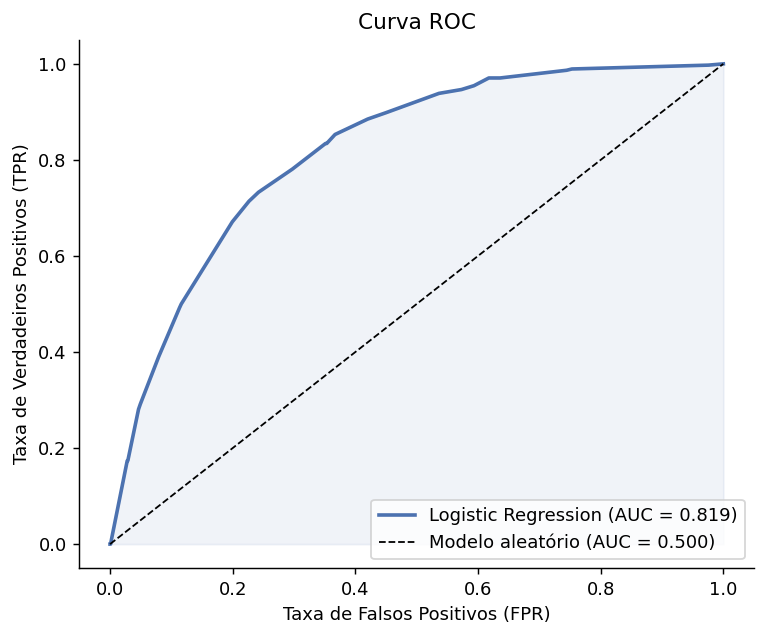

AUC-ROC: 0.8186


In [24]:
auc_roc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"Logistic Regression (AUC = {auc_roc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Modelo aleatório (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#4C72B0")
ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
ax.set_title("Curva ROC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AUC-ROC: {auc_roc:.4f}")

### 1.2 PR-AUC (Average Precision)

Mede o trade-off entre **Precisão** (quantos dos alertados realmente churnam) e **Recall** (quantos churners foram capturados).

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

- **Baseline** = taxa de churn da classe positiva (~26 %)
- **PR-AUC = 1.0**: perfeito | **PR-AUC = prevalência**: aleatório

**Quando usar**: datasets desbalanceados onde erros na classe minoritária (churners) têm custo elevado. É a métrica complementar ao AUC-ROC para churn.

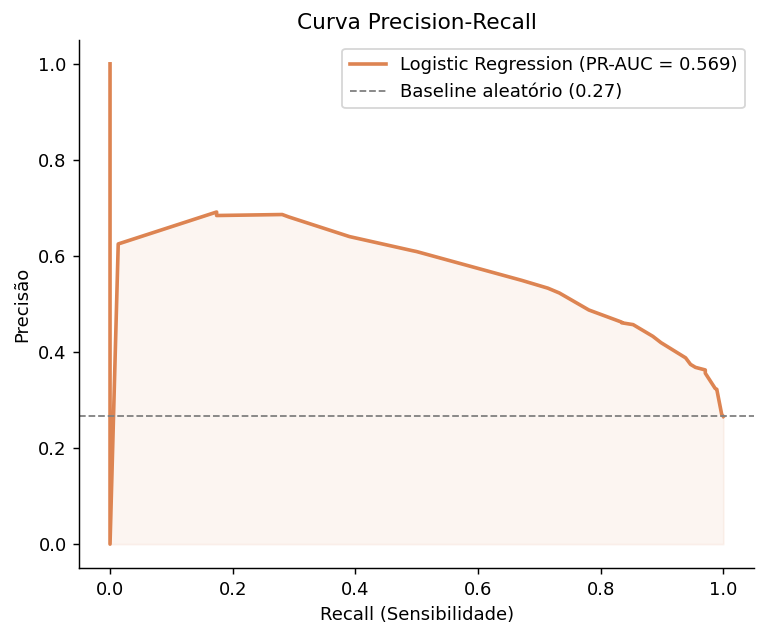

PR-AUC (Average Precision): 0.5694
Baseline aleatório equivalente: 0.2658


In [25]:
pr_auc = average_precision_score(y_test, y_prob)
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
baseline_rate = y_test.mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, color="#DD8452", lw=2, label=f"Logistic Regression (PR-AUC = {pr_auc:.3f})")
ax.axhline(baseline_rate, color="gray", linestyle="--", lw=1,
           label=f"Baseline aleatório ({baseline_rate:.2f})")
ax.fill_between(recall, precision, alpha=0.08, color="#DD8452")
ax.set_xlabel("Recall (Sensibilidade)")
ax.set_ylabel("Precisão")
ax.set_title("Curva Precision-Recall")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"Baseline aleatório equivalente: {baseline_rate:.4f}")

### 1.3 F1-Score

Média harmônica entre Precisão e Recall para um threshold fixo (padrão 0.5).

$$F1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

| Variante | Quando usar |
|---|---|
| **F1 macro** | Classes igualmente importantes |
| **F1 weighted** | Considera o suporte (tamanho) de cada classe |
| **F1 da classe positiva** | Foco em churners — nossa métrica principal |

**Limitação**: sensível ao threshold. Deve ser avaliado em conjunto com a curva PR para escolher o ponto ótimo de operação.

              precision    recall  f1-score   support

   Não-churn       0.85      0.88      0.86      1033
       Churn       0.63      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



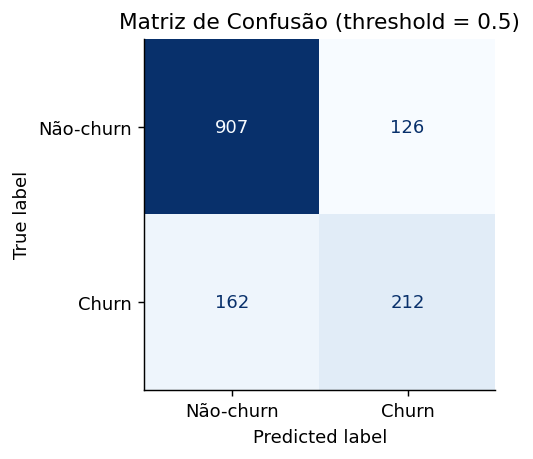

F1 (churn):    0.5955
F1 macro:      0.7292
F1 weighted:   0.7919


In [10]:
f1_churn = f1_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(classification_report(y_test, y_pred, target_names=["Não-churn", "Churn"]))

fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Não-churn", "Churn"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusão (threshold = 0.5)")
plt.tight_layout()
plt.show()

print(f"F1 (churn):    {f1_churn:.4f}")
print(f"F1 macro:      {f1_macro:.4f}")
print(f"F1 weighted:   {f1_weighted:.4f}")

## 2. Métrica de Negócio — Custo de Churn Evitado

### Premissas

| Parâmetro | Valor | Descrição |
|---|---|---|
| **CLV por churner** | `MonthlyCharges × 24` | Receita estimada dos próximos 24 meses |
| **Custo de retenção** | R$ 50 / cliente | Oferta/desconto para reter o cliente |
| **Taxa de sucesso da retenção** | 40 % | Percentual de churners que aceitam a oferta |
| **Custo de FP** | R$ 50 | Ação de retenção desperdiçada em não-churner |
| **Custo de FN** | CLV perdido | Churner não detectado → receita perdida |

### Fórmula do custo total

$$\text{Custo Total} = (\text{FP} \times C_{FP}) + (\text{FN} \times C_{FN}) - (\text{TP} \times \text{taxa\_retenção} \times \overline{CLV})$$

Minimizar o **Custo Total** = maximizar o **Custo de Churn Evitado**.

In [11]:
# --- Parâmetros de negócio ---
CLV_MONTHS        = 24      # janela de receita futura estimada
COST_RETENTION    = 50.0    # custo da ação de retenção por cliente (R$)
RETENTION_SUCCESS = 0.40    # 40% dos churners abordados são retidos
COST_FP           = 50.0    # custo de oferecer retenção a um não-churner (= COST_RETENTION)

# CLV médio dos churners no test set (usando MonthlyCharges do dataset original)
test_idx = X_test.index
monthly_charges_test = df.loc[test_idx, "MonthlyCharges"]
clv_per_customer = monthly_charges_test * CLV_MONTHS

churner_mask = y_test == 1
avg_clv_churner = clv_per_customer[churner_mask].mean()
print(f"CLV médio dos churners no test set: R$ {avg_clv_churner:,.2f}")


def compute_business_cost(y_true, y_pred_binary, clv_series, cost_fp, retention_success):
    """Retorna (custo_total, churn_evitado, economia_liquida)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()

    # Custo de falsos positivos: ações de retenção desnecessárias
    total_fp_cost = fp * cost_fp

    # Custo de falsos negativos: CLV perdido dos churners não detectados
    fn_mask = (y_true == 1) & (y_pred_binary == 0)
    total_fn_cost = clv_series[fn_mask].sum()

    # Receita recuperada pelos verdadeiros positivos que aceitam a oferta
    tp_mask = (y_true == 1) & (y_pred_binary == 1)
    churn_evitado = clv_series[tp_mask].sum() * retention_success

    custo_total = total_fp_cost + total_fn_cost - churn_evitado
    return {
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Custo FP (R$)": total_fp_cost,
        "Custo FN — CLV perdido (R$)": total_fn_cost,
        "Receita recuperada — churn evitado (R$)": churn_evitado,
        "Custo líquido total (R$)": custo_total,
    }


resultado = compute_business_cost(y_test, y_pred, clv_per_customer, COST_FP, RETENTION_SUCCESS)
print("\n=== Resultado com threshold = 0.5 ===")
for k, v in resultado.items():
    if isinstance(v, float):
        print(f"  {k}: R$ {v:>12,.2f}")
    else:
        print(f"  {k}: {v}")

CLV médio dos churners no test set: R$ 1,763.73

=== Resultado com threshold = 0.5 ===
  TP: 212
  FP: 126
  FN: 162
  TN: 907
  Custo FP (R$): R$     6,300.00
  Custo FN — CLV perdido (R$): R$   258,376.80
  Receita recuperada — churn evitado (R$): R$   160,503.84
  Custo líquido total (R$): R$   104,172.96


### 2.1 Varredura de threshold — encontrar o ponto ótimo de negócio

Diferente do F1 que usa threshold 0.5, o threshold ótimo de negócio é aquele que **minimiza o custo líquido total** (ou maximiza a receita recuperada).

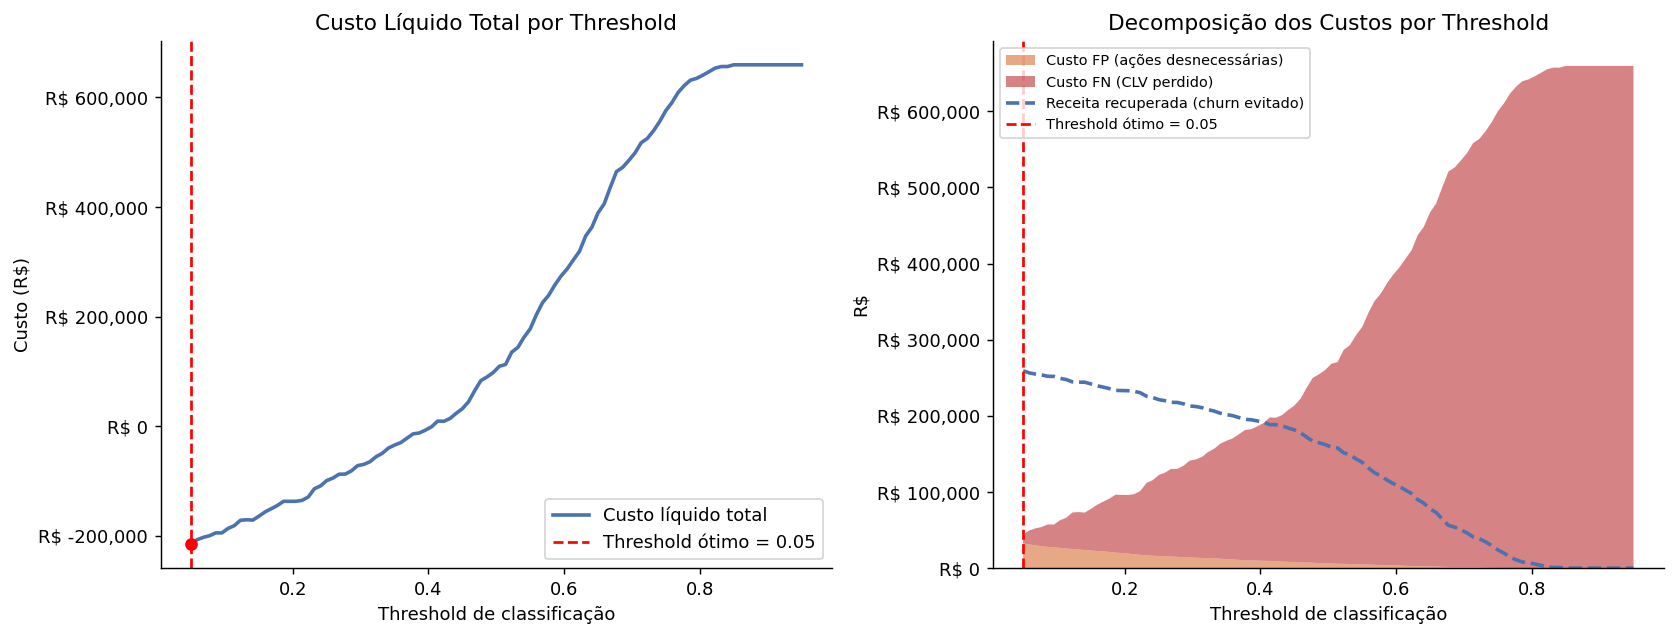


Threshold ótimo de negócio : 0.05
Custo líquido mínimo       : R$ -215,178.72
Receita recuperada         : R$ 259,204.32


In [12]:
thresholds = np.linspace(0.05, 0.95, 100)
custos, recuperados, custos_fp, custos_fn = [], [], [], []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    res = compute_business_cost(y_test, y_pred_t, clv_per_customer, COST_FP, RETENTION_SUCCESS)
    custos.append(res["Custo líquido total (R$)"])
    recuperados.append(res["Receita recuperada — churn evitado (R$)"])
    custos_fp.append(res["Custo FP (R$)"])
    custos_fn.append(res["Custo FN — CLV perdido (R$)"])

best_idx = np.argmin(custos)
best_threshold = thresholds[best_idx]
best_cost = custos[best_idx]
best_recovered = recuperados[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: custo líquido total ---
ax = axes[0]
ax.plot(thresholds, custos, color="#4C72B0", lw=2, label="Custo líquido total")
ax.axvline(best_threshold, color="red", linestyle="--", lw=1.5,
           label=f"Threshold ótimo = {best_threshold:.2f}")
ax.scatter([best_threshold], [best_cost], color="red", zorder=5)
ax.set_xlabel("Threshold de classificação")
ax.set_ylabel("Custo (R$)")
ax.set_title("Custo Líquido Total por Threshold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.legend()

# --- Plot 2: decomposição dos custos ---
ax2 = axes[1]
ax2.stackplot(thresholds, custos_fp, custos_fn,
              labels=["Custo FP (ações desnecessárias)", "Custo FN (CLV perdido)"],
              colors=["#DD8452", "#C44E52"], alpha=0.7)
ax2.plot(thresholds, recuperados, color="#4C72B0", lw=2, linestyle="--",
         label="Receita recuperada (churn evitado)")
ax2.axvline(best_threshold, color="red", linestyle="--", lw=1.5,
            label=f"Threshold ótimo = {best_threshold:.2f}")
ax2.set_xlabel("Threshold de classificação")
ax2.set_ylabel("R$")
ax2.set_title("Decomposição dos Custos por Threshold")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nThreshold ótimo de negócio : {best_threshold:.2f}")
print(f"Custo líquido mínimo       : R$ {best_cost:,.2f}")
print(f"Receita recuperada         : R$ {best_recovered:,.2f}")

## 3. Resumo e Critérios de Aceitação

| Métrica | Tipo | Meta mínima | Observação |
|---|---|---|---|
| **AUC-ROC** | Técnica | ≥ 0.80 | Comparação entre modelos |
| **PR-AUC** | Técnica | ≥ 0.65 | Principal para dados desbalanceados |
| **F1 (churn)** | Técnica | ≥ 0.60 | Com threshold padrão 0.5 |
| **Custo de churn evitado** | Negócio | Maximizar | Threshold ajustado por análise de custo |

### Hierarquia das métricas

1. **Custo de negócio** é o árbitro final — o modelo só vai para produção se reduzir o custo líquido
2. **PR-AUC** é o principal sinal técnico durante o desenvolvimento (desbalanceamento)
3. **AUC-ROC** é usado para comparação rápida entre experimentos
4. **F1** é reportado com o threshold de negócio ótimo (não necessariamente 0.5)

In [ ]:
print("=== Scorecard Final — Modelo de Referência (Logistic Regression) ===\n")

y_pred_opt = (y_prob >= best_threshold).astype(int)
res_opt = compute_business_cost(y_test, y_pred_opt, clv_per_customer, COST_FP, RETENTION_SUCCESS)

scores = {
    "AUC-ROC":                        f"{auc_roc:.4f}  (meta ≥ 0.80)",
    "PR-AUC":                         f"{pr_auc:.4f}  (meta ≥ 0.65)",
    "F1 (churn, threshold=0.5)":      f"{f1_churn:.4f}  (meta ≥ 0.60)",
    f"F1 (churn, threshold={best_threshold:.2f})": f"{f1_score(y_test, y_pred_opt):.4f}",
    "Threshold ótimo de negócio":     f"{best_threshold:.2f}",
    "Receita recuperada":             f"R$ {res_opt['Receita recuperada — churn evitado (R$)']:,.2f}",
    "Custo líquido total":            f"R$ {res_opt['Custo líquido total (R$)']:,.2f}",
}

for k, v in scores.items():
    print(f"  {k:<42} {v}")

## 4. Registrar no MLflow

As células anteriores já calcularam tudo. Esta célula consolida num único run.

In [ ]:
# Parâmetros de negócio definidos na seçao 2
_business_params = dict(
    clv_months        = CLV_MONTHS,
    cost_retention    = COST_RETENTION,
    retention_success = RETENTION_SUCCESS,
    cost_fp           = COST_FP,
)

# Resultado com threshold ta bom demais (já calculado na varredura)
_res_opt = compute_business_cost(y_test, y_pred_opt, clv_per_customer, COST_FP, RETENTION_SUCCESS)

with mlflow.start_run(run_name="logistic_regression_metrics_definition") as run:

    # — tags de dataset
    mlflow.set_tags({
        "dataset.name":       "telco_churn",
        "dataset.source":     "data/raw/telco_churn.csv",
        "dataset.md5":        DATASET_MD5,
        "dataset.git_commit": DATASET_COMMIT,
        "dataset.n_rows":     str(len(df)),
        "dataset.n_features": str(X.shape[1]),
        "notebook":           "Metricas.ipynb",
        "model.type":         "LogisticRegression",
    })

    # — parâmetros do modelo e split
    mlflow.log_params({
        "model":           "LogisticRegression",
        "test_size":       0.2,
        "random_state":    42,
        "encoding":        "LabelEncoder (todas as categoricas)",
        "drop_features":   "customerID",
        # parâmetros de negócio
        "biz.clv_months":          CLV_MONTHS,
        "biz.cost_retention":      COST_RETENTION,
        "biz.retention_success":   RETENTION_SUCCESS,
        "biz.cost_fp":             COST_FP,
    })

    # — métricas técnicas (threshold padrão 0.5)
    mlflow.log_metrics({
        "test.auc_roc":   auc_roc,
        "test.pr_auc":    pr_auc,
        "test.f1_churn":  f1_churn,
        "test.f1_macro":  f1_macro,
        "test.f1_weighted": f1_weighted,
    })

    # — métricas de negócio com threshold ótimo
    mlflow.log_metrics({
        "biz.threshold_optimal":    best_threshold,
        "biz.revenue_recovered":    best_recovered,
        "biz.net_cost_optimal":     best_cost,
        "biz.tp_optimal":           int(_res_opt["TP"]),
        "biz.fp_optimal":           int(_res_opt["FP"]),
        "biz.fn_optimal":           int(_res_opt["FN"]),
        "biz.cost_fp_total":        _res_opt["Custo FP (R$)"],
        "biz.cost_fn_total":        _res_opt["Custo FN — CLV perdido (R$)"],
    })

    # — modelo serializado
    signature = mlflow.models.infer_signature(X_train, clf.predict_proba(X_train)[:, 1])
    mlflow.sklearn.log_model(clf, artifact_path="model", signature=signature)

    RUN_ID = run.info.run_id

print(f"Run registrado: {RUN_ID}")
print(f"\nMétricas técnicas  → test.auc_roc={auc_roc:.4f} | test.pr_auc={pr_auc:.4f} | test.f1={f1_churn:.4f}")
print(f"Métrica de negócio → threshold={best_threshold:.2f} | receita recuperada=R$ {best_recovered:,.2f}")